In [72]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Hyperparameters (tune these explicitly) ──────-────────────────────────────
ALT_SG_WINDOW   = 61   # Savitzky-Golay window for altitude  (must be odd)
ALT_SG_POLY     = 2    # polynomial order for altitude smoothing
SPD_SG_WINDOW   = 15   # Savitzky-Golay window for velocity
SPD_SG_POLY     = 2    # polynomial order for velocity smoothing
MIN_DIST_M      = 50   #min. distance for calculating gradient 
MIN_SPEED_GRADIENT = 3 #min. speed for gradient to be deemed valid
GRADIENT_CLIP   = 0.15  # hard clip after computation
COMPLEMENTARY_ALPHA  = 0.97   # gyro weight; tune between 0.95–0.99
GYRO_PITCH_AXIS      = "GY"   # placeholder — confirm from stationary test
ACC_FORWARD_AXIS     = "AX"   # placeholder — confirm from stationary test
ACC_VERTICAL_AXIS    = "AZ"   # placeholder — confirm from stationary test

# ── 0. Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv('Data/dataset.csv')

# ── 1. Retain only valid year rows; drop irrelevant columns ───────────────────
df = df[df["Y"] == 23].reset_index(drop=True)
df.drop(columns=["id", "LAT", "LON", "VOL", "ODO", "AUT"], inplace=True)

# ── 2. Remove ECO mode ────────────────────────────────────────────────────────
df = df[df["ECO"] != 192].reset_index(drop=True)
df.drop(columns = ["ECO"])

df.describe().T[['mean', 'std', 'min', '50%', 'max']]
print(pd.__version__)



3.0.5


In [73]:
# ── 3. Reconstruct timestamp → compute dt per driver, then drop raw cols ──────
# Build a proper datetime from components
df["timestamp"] = pd.to_datetime({
    "year":   2000 + df["Y"],   # Y=23 → 2023
    "month":  df["M"],
    "day":    df["D"],
    "hour":   df["H"],
    "minute": df["MIN"],
    "second": df["SEC"]
})

# Sort within each driver by time (never assume CSV order is chronological)
df = df.sort_values(["COND", "timestamp"]).reset_index(drop=True)

# dt in seconds, within each driver only — boundary rows get NaN
df["dt"] = df.groupby("COND")["timestamp"].diff().dt.total_seconds()

# Drop raw timestamp columns — dt is all we need
df.drop(columns=["Y", "M", "D", "H", "MIN", "SEC", "timestamp"], inplace=True)
df = df[df['dt'] <= 10]
df.describe().T[['mean', 'std', 'min', '50%', 'max']]

,mean,std,min,50%,max
COND,4.806506,2.403869,1.0,5.00,9.0
ALT,1080.120857,197.807420,0.0,1189.35,1352.4
AX,148.801611,303.797543,-950.0,105.00,2426.0
AY,855.108897,220.077548,-159.0,856.00,1837.0
AZ,1888.335138,290.425572,-1539.0,1887.00,5181.0
GX,-2.999350,36.253199,-709.0,-4.00,542.0
GY,-6.502556,52.184626,-408.0,-6.00,959.0
GZ,-0.194533,63.858420,-645.0,1.00,699.0
CH,67.987243,19.250081,21.0,67.50,99.5
CUR,27.627870,54.268789,-52.0,8.00,301.0


In [74]:
# ── 4. Unit conversion: velocity km/h → m/s ───────────────────────────────────
df["SPD_ms"] = df["SPD"] / 3.6

# Convert raw IMU to physical units — do this on full df before train/test split
for col in ["AX", "AY", "AZ"]:
    df[col] = df[col] / 2048.0 * 9.81      # → m/s²

for col in ["GX", "GY", "GZ"]:
    df[col] = df[col] / 16.4               # → degrees/s
    
df[["GX", "GY", "GZ"]] = df[["GX", "GY", "GZ"]] * (np.pi / 180)  # → rad/s

# ── 5. Split by driver before any smoothing ───────────────────────────────────
drivers = df["COND"].unique()
print(drivers)
np.random.seed(42)
np.random.shuffle(drivers)

train_drivers = drivers[:7]
test_drivers  = drivers[7:]

train_df = df[df["COND"].isin(train_drivers)].copy()
test_df  = df[df["COND"].isin(test_drivers)].copy()

# ── 6. AC power subtraction ───────────────────────────────────────────────────
def subtract_ac_current(df):
    df = df.copy()
    rest = (df["SPD"] == 0) & (df["BRK"] == 0) & (df["ACC"] == 0)
    ac_on_current  = df.loc[rest & (df["AIR"] == 2),  "CUR"].median()
    ac_off_current = df.loc[rest & (df["AIR"] == 0),  "CUR"].median()
    ac_draw = ac_on_current - ac_off_current
    print(f"  Estimated AC current draw: {ac_draw:.3f} A")
    df.loc[df["AIR"] == 2, "CUR"] -= ac_draw
    return df

train_df = subtract_ac_current(train_df)
test_df  = subtract_ac_current(test_df)

test_df.drop(columns = ["BRK", "ACC"])
train_df.drop(columns = ["BRK", "ACC"])

# ── 7. Remove negative current (regen omitted entirely) ───────────────────────
train_df = train_df[train_df["CUR"] >= 0].reset_index(drop=True)
test_df  = test_df[test_df["CUR"]  >= 0].reset_index(drop=True)
print(train_df.columns)
train_df.tail()

[1 2 3 4 5 6 7 8 9]
  Estimated AC current draw: 4.000 A
  Estimated AC current draw: 3.000 A
Index(['COND', 'ALT', 'AX', 'AY', 'AZ', 'GX', 'GY', 'GZ', 'CH', 'CUR', 'SPD',
       'BRK', 'ACC', 'ECO', 'AIR', 'dt', 'SPD_ms'],
      dtype='str')


,COND,ALT,AX,AY,AZ,GX,GY,GZ,CH,CUR,SPD,BRK,ACC,ECO,AIR,dt,SPD_ms
12479,9,1205.0,0.086221,5.829478,8.430469,0.034055,0.038312,0.092588,82.0,147,85,0,38,0,2,1.0,23.611111
12480,9,1202.9,2.533931,3.975732,9.278306,0.026606,0.003193,0.011706,81.5,76,82,0,36,0,2,1.0,22.777778
12481,9,1201.7,2.332749,4.555327,8.794512,-0.034055,-0.038312,0.018092,81.5,75,90,0,4,0,2,2.0,25.000000
12482,9,1201.9,2.936294,3.156636,7.865244,0.001064,0.015963,0.025541,81.5,112,90,0,26,0,2,1.0,25.000000
12483,9,1201.3,1.657354,3.731440,9.216035,0.008514,0.024477,0.018092,81.5,2,90,0,22,0,2,2.0,25.000000


In [75]:
# ── 8. Per-driver smoothing → gradient and acceleration ───────────────────────
def process_driver_group(group, alt_window, alt_poly, spd_window, spd_poly):
    group = group.copy()
    n = len(group)

    # Savitzky-Golay requires window < n and window must be odd
    aw = min(alt_window, n if n % 2 == 1 else n - 1)
    
    def valid_window(w, n):
        w = min(w, n - 1 if (n - 1) % 2 == 1 else n - 2)
        return w if w % 2 == 1 else w - 1

    sw = valid_window(spd_window, n)

    dt = group["dt"].fillna(0).values

    # ── Step 1: Accelerometer-only pitch estimate ─────────────────────────────
    # Valid only when vehicle is not accelerating (gravity dominates)
    # Replace AX/AZ with whichever axes you confirm from the stationary test
    a_fwd  = group[ACC_FORWARD_AXIS].values
    a_vert = group[ACC_VERTICAL_AXIS].values

    # Clamp to [-1, 1] before arcsin to avoid NaN from floating point noise
    sin_theta = np.clip(a_fwd / 9.81, -1.0, 1.0)
    theta_accel = np.arcsin(sin_theta)   # radians
    
    # ── Step 2: Gyroscope integration (pitch rate axis) ───────────────────────
    gyro_pitch = group[GYRO_PITCH_AXIS].values   # rad/s after conversion

    theta_comp = np.zeros(n)
    theta_comp[0] = theta_accel[0]   # initialise from accelerometer

    for i in range(1, n):
        # Gyro integrates forward; accelerometer corrects drift
        gyro_pred = theta_comp[i-1] + gyro_pitch[i] * dt[i]
        theta_comp[i] = (COMPLEMENTARY_ALPHA * gyro_pred +
                         (1 - COMPLEMENTARY_ALPHA) * theta_accel[i])

    group["theta_imu"] = theta_comp
    
    # ── Step 3: Reliability flag ──────────────────────────────────────────────
    # Accelerometer pitch estimate is unreliable when kinematic accel is large
    # (can't separate gravity from vehicle acceleration)
    # Use smoothed speed diff as a rough kinematic accel estimate for flagging
    group["SPD_smooth"] = savgol_filter(group["SPD_ms"],
                                        window_length=sw, polyorder=spd_poly)
    d_spd = np.gradient(group["SPD_smooth"].values)   # unitless differences, uniform spacing
    raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real
    group["accel_imu"] = raw_accel

    # Flag rows where kinematic accel is large — theta_accel is less trustworthy
    # The complementary filter handles this partially, but flag it anyway
    group["gradient_reliable"] = (
        (group["SPD_ms"] >= MIN_SPEED_GRADIENT) &
        (np.abs(raw_accel) < 2.0)               # m/s² — not aggressively accelerating
    ).astype(float)

    # Zero boundary row
    first_idx = group.index[0]
    group.loc[first_idx, ["theta_imu", "accel_imu", "gradient_reliable"]] = 0.0

    return group
    

    #--- Velocity smoothing → acceleration ---
    group["SPD_smooth"] = savgol_filter(group["SPD_ms"], window_length=sw, polyorder=spd_poly)
    group["accel"] = np.where(
        group["dt"].fillna(0) > 0,
        group["SPD_smooth"].diff() / group["dt"].fillna(1),
        0
    )
    group["accel"] = group["accel"].fillna(0)

    # Zero out boundary row artifacts
    group.loc[group["dt"].isna(), ["gradient", "theta", "accel", "dist_m"]] = 0

    return group

def apply_per_driver(df):
    result = []

    for cond, group in df.groupby("COND"):
        processed = process_driver_group(
            group, ALT_SG_WINDOW, ALT_SG_POLY,
            SPD_SG_WINDOW, SPD_SG_POLY
        )
        processed["COND"] = cond
        result.append(processed)

    return pd.concat(result, ignore_index=True)

train_df = apply_per_driver(train_df)
test_df  = apply_per_driver(test_df)

C:\Users\HP\AppData\Local\Temp\ipykernel_21172\2323947149.py:48: RuntimeWarning: divide by zero encountered in divide
  raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real
C:\Users\HP\AppData\Local\Temp\ipykernel_21172\2323947149.py:48: RuntimeWarning: divide by zero encountered in divide
  raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real
C:\Users\HP\AppData\Local\Temp\ipykernel_21172\2323947149.py:48: RuntimeWarning: divide by zero encountered in divide
  raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real
C:\Users\HP\AppData\Local\Temp\ipykernel_21172\2323947149.py:48: RuntimeWarning: divide by zero encountered in divide
  raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real
C:\Users\HP\AppData\Local\Temp\ipykernel_21172\2323947149.py:48: RuntimeWarning: divide by zero encountered in divide
  raw_accel = np.where(dt > 0.5, d_spd / dt, 0.0)  # divide only where dt is real


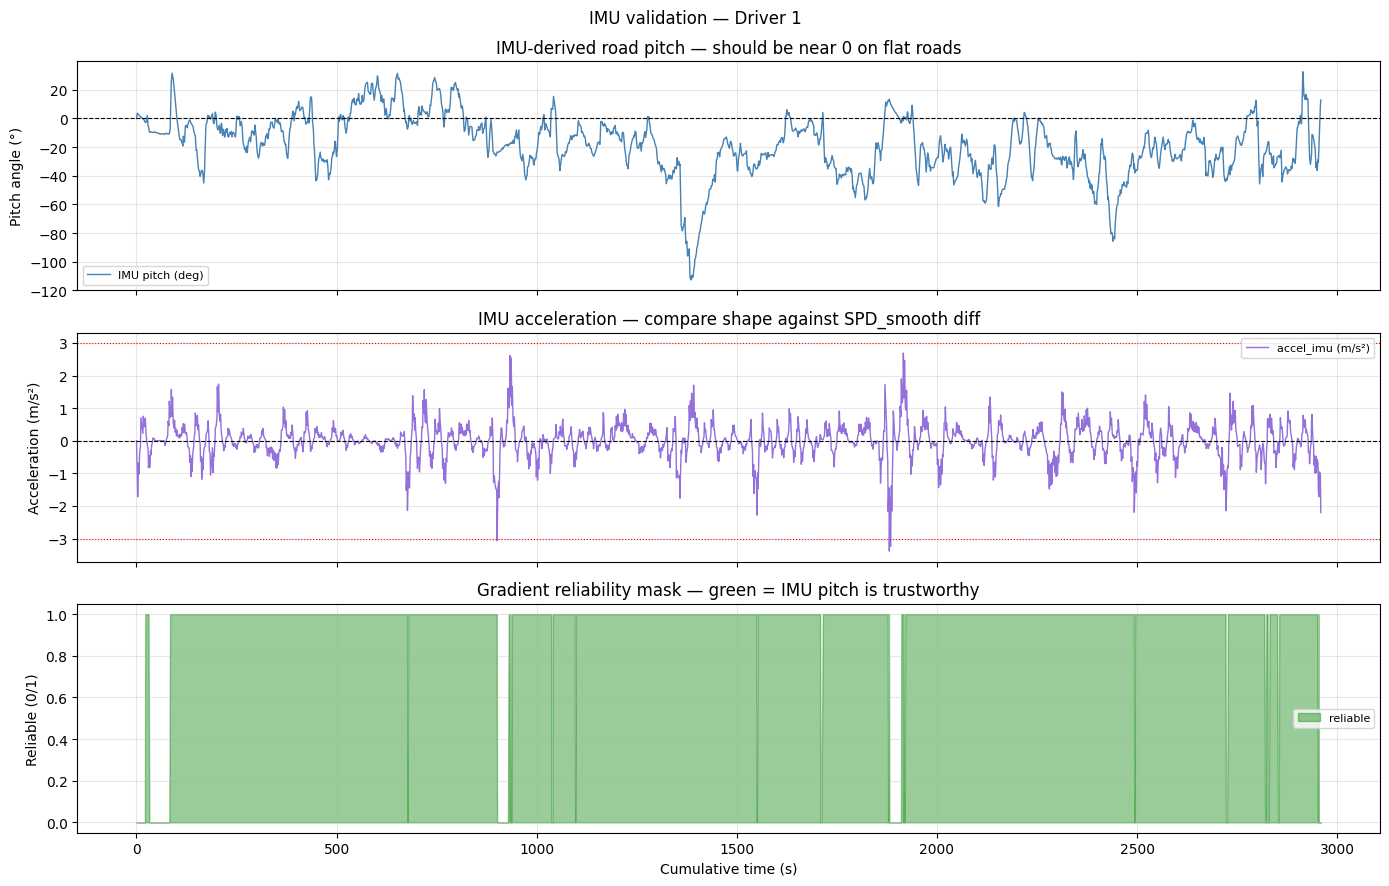

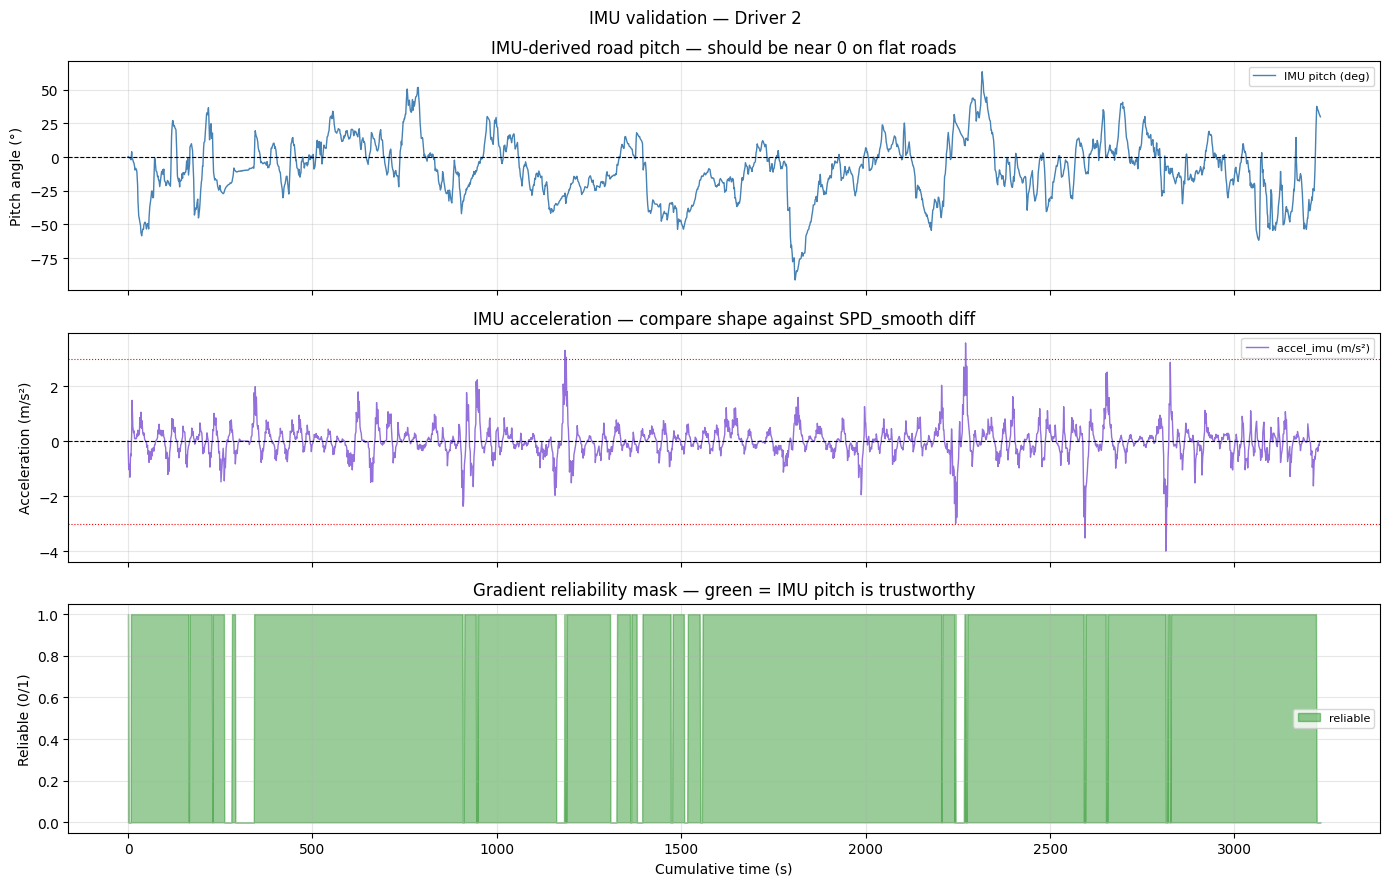

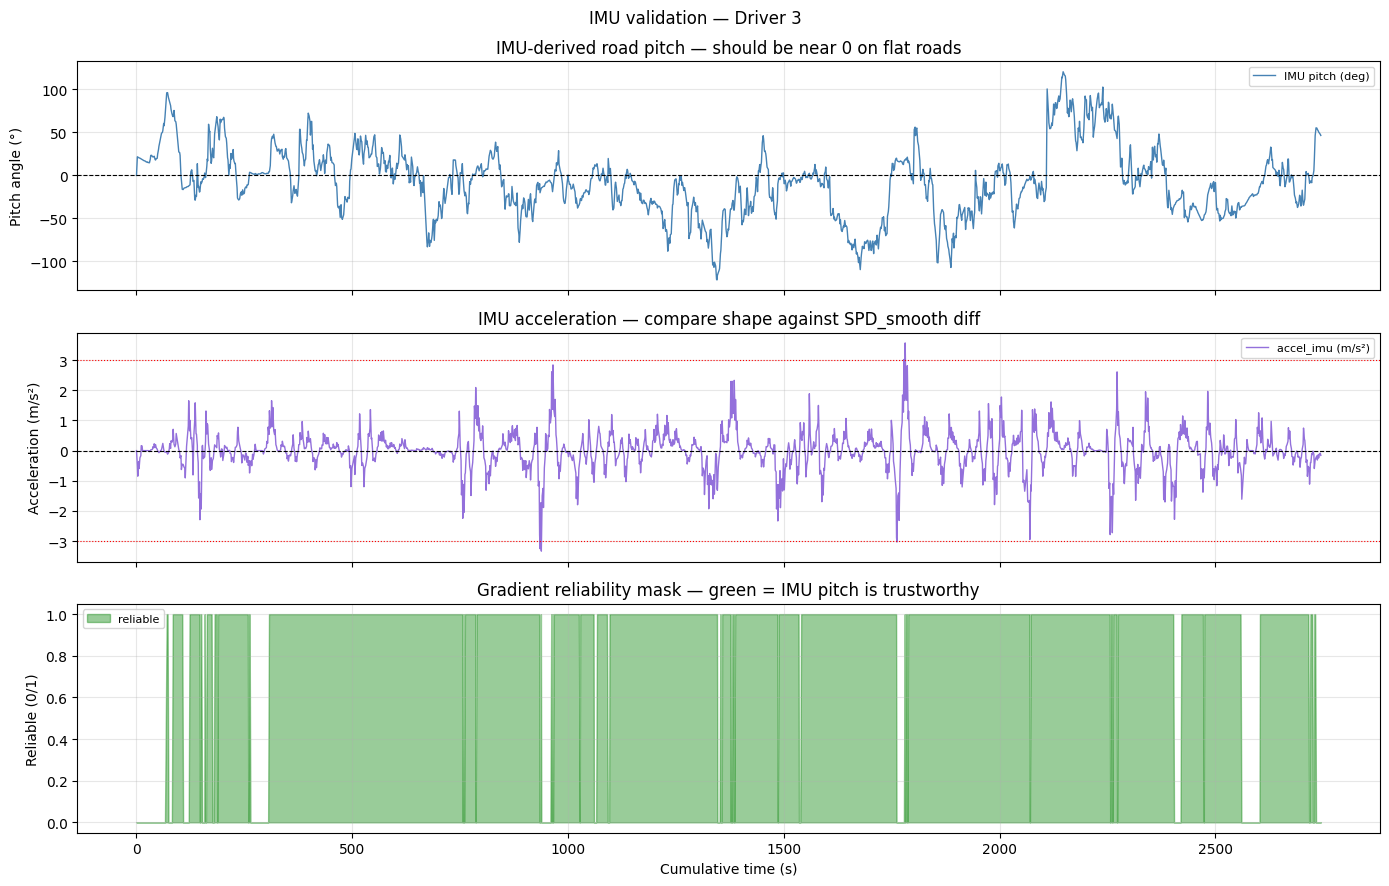

In [76]:
def plot_imu_validation(df, cond):
    seg = df[df["COND"] == cond].reset_index(drop=True)
    t   = seg["dt"].fillna(0).cumsum()

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"IMU validation — Driver {cond}", fontsize=12)

    # Panel 1: theta from IMU vs GPS (if you still have ALT columns)
    axes[0].plot(t, np.degrees(seg["theta_imu"]),
                 color="steelblue", lw=1, label="IMU pitch (deg)")
    axes[0].axhline(0, color="black", lw=0.8, ls="--")
    axes[0].set_ylabel("Pitch angle (°)")
    axes[0].set_title("IMU-derived road pitch — should be near 0 on flat roads")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # Panel 2: IMU acceleration vs velocity-derived acceleration
    axes[1].plot(t, seg["accel_imu"],
                 color="mediumpurple", lw=1, label="accel_imu (m/s²)")
    axes[1].axhline(0,  color="black", lw=0.8, ls="--")
    axes[1].axhline( 3, color="red",   lw=0.8, ls=":")
    axes[1].axhline(-3, color="red",   lw=0.8, ls=":")
    axes[1].set_ylabel("Acceleration (m/s²)")
    axes[1].set_title("IMU acceleration — compare shape against SPD_smooth diff")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # Panel 3: reliability flag
    axes[2].fill_between(t, seg["gradient_reliable"],
                          color="green", alpha=0.4, label="reliable")
    axes[2].set_ylabel("Reliable (0/1)")
    axes[2].set_xlabel("Cumulative time (s)")
    axes[2].set_title("Gradient reliability mask — green = IMU pitch is trustworthy")
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for cond in train_df["COND"].unique()[:3]:
    plot_imu_validation(train_df, cond)

In [77]:
# ── Speed threshold ───────────────────────────────────────────────────────────
SPEED_THRESHOLD_MS = 50 / 3.6   # 50 km/h in m/s ≈ 13.89 m/s

# ── Split by regime ───────────────────────────────────────────────────────────
train_low  = train_df[train_df["SPD_ms"] <  SPEED_THRESHOLD_MS].reset_index(drop=True)
train_high = train_df[train_df["SPD_ms"] >= SPEED_THRESHOLD_MS].reset_index(drop=True)
test_low   = test_df[test_df["SPD_ms"]   <  SPEED_THRESHOLD_MS].reset_index(drop=True)
test_high  = test_df[test_df["SPD_ms"]   >= SPEED_THRESHOLD_MS].reset_index(drop=True)

print(f"Train — low speed: {len(train_low):,} rows | high speed: {len(train_high):,} rows")
print(f"Test  — low speed: {len(test_low):,}  rows | high speed: {len(test_high):,}  rows")

# ── Regime-specific feature sets ──────────────────────────────────────────────
# Low speed: v³ negligible, drop it. Inertia and accessories dominate.
def build_features_low(df):
    v   = df["SPD_ms"]
    a   = df["accel"]
    th  = df["theta"]
    soc = df["CH"]
    return pd.DataFrame({
        "v_a":      v * a,
        "v_sin_th": v * np.sin(th),
        "v":        v,
        "SOC":      soc,
        "const":    1.0
    }, index=df.index)

# High speed: v³ dominates. Keep all terms.
def build_features_high(df):
    v   = df["SPD_ms"]
    a   = df["accel"]
    th  = df["theta"]
    soc = df["CH"]
    return pd.DataFrame({
        "v3":       v ** 3,
        "v_a":      v * a,
        "v_sin_th": v * np.sin(th) ,
        "v":        v,
        "SOC":      soc,
        "const":    1.0
    }, index=df.index)

# ── Fit and evaluate both models ──────────────────────────────────────────────
for label, train_r, test_r, feat_fn in [
    ("Low speed  (<50 km/h)", train_low,  test_low,  build_features_low),
    ("High speed (≥50 km/h)", train_high, test_high, build_features_high),
]:
    X_tr = feat_fn(train_r)
    X_te = feat_fn(test_r)
    y_tr = train_r["CUR"]
    y_te = test_r["CUR"]

    m = LinearRegression(fit_intercept=False)
    m.fit(X_tr, y_tr)
    y_pr = m.predict(X_te)

    print(f"\n── {label} ──────────────────────────────────────")
    for feat, coef in zip(X_tr.columns, m.coef_):
        print(f"  {feat:15s}: {coef:.6f}")
    print(f"\n  R²:   {r2_score(y_te, y_pr):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(y_te, y_pr)):.3f} A")
    print(f"  Test rows: {len(y_te):,}")

Train — low speed: 4,879 rows | high speed: 7,605 rows
Test  — low speed: 1,513  rows | high speed: 1,991  rows


KeyError: 'accel'

In [ ]:
# ── 9. Feature engineering ────────────────────────────────────────────────────
# Target: CUR (current in amps)
# Features derived from road-load physics:
#   k1·v³  → aerodynamic drag
#   k2·v·a → inertial load
#   k3·v·sin(θ) → gravitational climbing load
#   k4·v   → rolling resistance
#   k5·SOC → efficiency variation with state of charge
#   k6     → constant idle/accessory load

def build_features(df):
    v   = df["SPD_ms"]
    a   = df["accel"]
    th  = df["theta"]
    soc = df["CH"]          # battery charge % as SOC proxy
    return pd.DataFrame({
        "v3":       v ** 3,
        "v_a":      v * a,
        "v_sin_th": v * np.sin(th),
        "v":        v,
        "SOC":      soc,
        "const":    1.0
    }, index=df.index)

X_train = build_features(train_df)
y_train = train_df["CUR"]

X_test  = build_features(test_df)
y_test  = test_df["CUR"]


In [ ]:


# ── 10. Linear regression ─────────────────────────────────────────────────────
model = LinearRegression(fit_intercept=False)   # const term already in X
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n── Model Results ──────────────────────────────")
for feat, coef in zip(X_train.columns, model.coef_):
    print(f"  {feat:12s}: {coef:.6f}")
print(f"\n  R²:   {r2_score(y_test, y_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f} A")




── Model Results ──────────────────────────────
  v3          : 0.001135
  v_a         : 1.548726
  v_sin_th    : 39.450669
  v           : 1.799827
  SOC         : -0.227254
  const       : 22.596192

  R²:   0.3062
  RMSE: 38.535 A
